Data created using Mockaroo - https://mockaroo.com/

In [2]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from itertools import count
import pandas as pd
import numpy as np
from IPython.display import HTML

In [3]:
df = pd.read_csv("MOCK_DATA.csv")
df.head() # display the first 5 rows

,id,date,price
0,1,72,457
1,2,277,139
2,3,207,115
3,4,86,386
4,5,49,62


In [4]:
df_sorted = df.sort_values("date", ascending=True).drop("id", axis="columns")
df_sorted.head(10)

,date,price
124,1,329
967,1,285
136,2,409
329,2,338
973,2,496
387,2,209
384,3,87
249,3,188
113,3,405
628,3,253


In [5]:
x_val = df_sorted["date"].to_numpy()
y_val = df_sorted["price"].to_numpy()

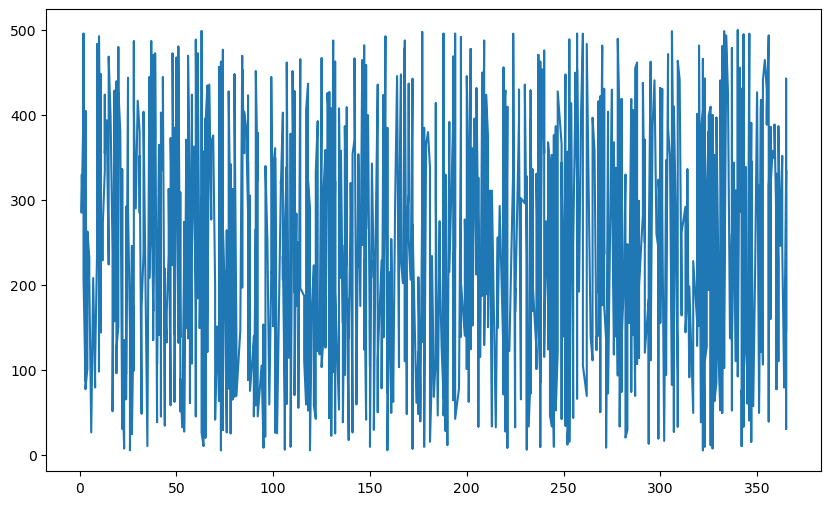

In [6]:
plt.figure(figsize=(10, 6))
plt.plot(x_val,y_val)
plt.show()

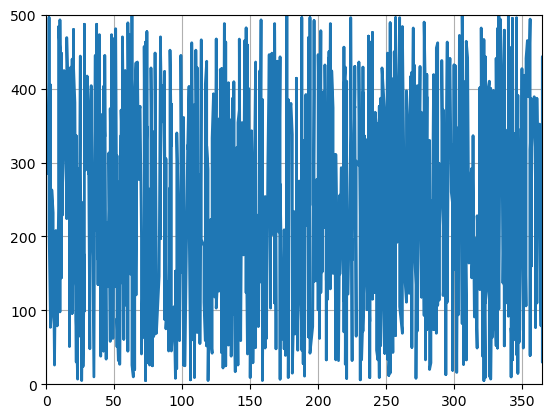

In [7]:
fig, ax = plt.subplots()
line, = ax.plot([], [], lw=2)
ax.grid()
xdata, ydata = [],[]

def data_gen():
    for cnt in count():
        yield x_val[cnt], y_val[cnt]

def init():
    ax.set_ylim(0,500)
    ax.set_xlim(0,365)
    line.set_data(xdata, ydata)
    return line

def run(data):
    t, y = data
    xdata.append(t)
    ydata.append(y)
    line.set_data(xdata,ydata)
    return line,

anim = animation.FuncAnimation(fig, run, data_gen, interval=100, init_func=init, save_count=1000)

HTML(anim.to_html5_video())